In [ ]:
import os
os.chdir("/data/local/mvaquerizo/transcriptomica/")

### Libraries

In [2]:
import sklearn as sk
import pandas as pd
import statistics as st
import numpy as np
from scripts.Funciones.Funciones import corr_loop, pca_plot, accuracy_models, prob_to_clase, performance_modelo, rendimiento_train, rendimiento_test
import scipy.stats as sc
import igraph as ig
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold, KFold, RepeatedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from multiprocessing import Pool
import pickle
import random


### Load data

In [ ]:
data = pd.read_csv('results/06_exploratory_and_DEA_limma/conteos_finales.csv', index_col=0)

,PIF_BI10,PIF_BI20,PIF_P37,PIF_P8,PIF_V56,PIF_B19,PIF_B28,PIF_BI14,PIF_P6,PIF_M8,...,ENC_R41,ENC_Bi10,ENC_R46,ENC_V16,ENC_B34,ENC_B35,ENC_B38,ENC_Bi21,ENC_V33,ENC_B12
WASH7P,1.416956,2.150675,2.410188,4.496283,2.137458,2.409733,3.688824,2.645052,2.032795,2.335017,...,1.281114,2.482424,1.946009,2.367969,1.084374,1.864328,0.998378,3.882634,2.179226,2.304804
LOC729737,2.486933,1.914562,0.957675,2.366079,-0.635290,3.912570,1.422141,2.881861,2.715712,1.538500,...,0.819952,1.923240,1.582823,2.397145,-0.300468,0.867535,1.772990,2.534721,2.386626,1.983932
OR4F3,2.506844,2.626319,1.792584,0.963817,3.725479,1.001411,1.483879,1.463692,2.781373,0.072682,...,0.306521,2.458734,0.289454,0.992456,-1.629756,1.270144,-0.239184,3.647641,3.308280,3.422612
LINC00115,2.627189,2.978013,2.950424,3.321384,1.879922,3.326740,2.356104,2.416914,3.113539,3.053060,...,1.228514,3.647642,1.943296,2.223973,1.960289,1.431430,1.744550,3.959604,3.922121,3.522578
LOC643837,3.426566,2.889866,3.172734,2.283649,2.775364,3.235707,2.512665,2.869325,3.126200,3.567046,...,3.733544,3.523876,3.984205,3.509307,3.441018,3.648065,3.780715,3.555065,2.993793,2.605577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FER1L4,1.298604,1.574143,1.818139,2.181592,1.154298,1.389565,2.248923,1.631111,1.464025,2.106421,...,0.361421,2.291553,1.147990,2.408343,0.328196,0.463799,0.073092,2.260956,2.721791,2.401736
HLA-B,7.538460,7.601285,5.590700,6.573674,6.109324,8.429804,8.405248,7.211955,6.224288,4.863674,...,6.347737,7.610228,6.386557,7.153547,7.372567,5.833219,7.010843,6.744905,5.615504,4.657256
MILR1,1.511858,0.718286,1.114791,0.730971,1.125609,1.240722,0.494125,0.971053,0.962772,-0.506271,...,1.141470,0.857004,0.650311,-1.073805,0.752226,0.858591,0.479263,0.821013,-0.419516,1.198850
SNORA19,4.872321,3.838647,4.949631,6.103236,5.524111,2.518479,1.632185,2.513953,3.329258,3.324792,...,4.429688,2.670759,2.607468,4.257273,3.364688,2.865633,3.013033,4.068920,3.207632,2.893268


In [ ]:
ed = pd.read_csv('results/06_exploratory_and_DEA_limma/metadata.csv', index_col=0)

,id_met,id_trans,age,bmi,outcome,p4_hours,TED,DV200,RIN,project,g_acc,estado_embrion,calidad_embrion,origen_ovocito,estado_ovocito,pgt,pub,ciclo
PIF_BI10,PAT_10,PIF_BI10,37,24.87,LB,130.200000,R2,71.87,5.9,PIF,R,Frozen,B,Own,Frozen,Euploid,False,Substituted
PIF_BI20,PAT_17,PIF_BI20,39,21.98,NB,117.333333,R1,81.99,3.1,PIF,R,Fresh,B,Donated,Frozen,NO_PGT,True,Substituted
PIF_P37,PAT_15,PIF_P37,38,20.70,LB,113.583333,PR,82.45,4.9,PIF,E,Frozen,B,Own,Fresh,Euploid,False,Substituted
PIF_P8,PAT_113,PIF_P8,36,21.38,NB,113.833333,PR,78.52,3.7,PIF,E,Fresh,A,Donated,Vitrified,NO_PGT,False,Substituted
PIF_V56,PAT_45,PIF_V56,48,26.08,NB,115.500000,PR,84.35,4.5,PIF,R,Fresh,B,Donated,Frozen,NO_PGT,False,Substituted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENC_B35,PAT_60,ENC_B35,38,20.96,M,126.000000,PR-R1,81.98,8.6,ENC,R,Frozen,B,Own,Fresh,Euploid,False,Substituted
ENC_B38,PAT_77,ENC_B38,41,21.56,LB,126.833333,R2,85.68,9.1,ENC,E,Frozen,B,Own,Fresh,Euploid,False,Substituted
ENC_Bi21,PAT_103,ENC_Bi21,33,21.44,NB,123.833333,R2,85.23,8.4,ENC,E,Frozen,B,Own,Fresh,Euploid,False,Substituted
ENC_V33,PAT_153,ENC_V33,37,21.45,LB,109.250000,PR,85.50,8.7,ENC,E,Frozen,A,Own,Fresh,Euploid,True,HRT


### Clasificación
Separamos las muestras en envejecidas (E) y rejuvenecidas (R) en base a los datos epigenéticos

In [5]:
ed.index.tolist() == data.columns.tolist()

True

In [6]:
classification = pd.DataFrame({'sample': ed.index.tolist(), 
                              'class': list(ed.g_acc),
                              'class_numeric': ed.g_acc.map({'R':0, 'E':1})},
                              index = ed.index.tolist())
classification

,sample,class,class_numeric
PIF_BI10,PIF_BI10,R,0
PIF_BI20,PIF_BI20,R,0
PIF_P37,PIF_P37,E,1
PIF_P8,PIF_P8,E,1
PIF_V56,PIF_V56,R,0
...,...,...,...
ENC_B35,ENC_B35,R,0
ENC_B38,ENC_B38,E,1
ENC_Bi21,ENC_Bi21,E,1
ENC_V33,ENC_V33,E,1


### Selección de genes
Nos queremos quedar con aquellos genes correlacionados con la clase, pero que estén poco correlacionados entre sí para evitar colinealidad

In [ ]:
# Cálculo correlación gen - clase 
corr1 = pd.DataFrame()
for i in range(0,data.shape[0]):
    res = sc.spearmanr(data.iloc[i,:], classification.loc[:,'class_numeric'])
    res2 = pd.DataFrame.from_dict({'R': [res.statistic], 'p_value': [res.pvalue]})
    corr1 = pd.concat([corr1, res2])

In [ ]:
# Nos quedamos solo con aquellos genes con correlación positiva con la clase
corr1.index = data.index
corr1['Genes'] = corr1.index
corr_genes = corr1[corr1['p_value']<=0.05].index.to_list()
subdat = data.loc[corr_genes, :]
subdat.shape

(603, 50)

In [128]:
# Calculamos la correlación gen a gen 
index_loop = []
for i in range(0,subdat.shape[0]):
    for j in range(i+1, subdat.shape[0]):
        index_loop.append((subdat,i,j))

with Pool() as pool:
    results = pool.map(corr_loop, index_loop)
corr2 = pd.concat(results)
corr2

,Gene1,Gene2,R,p_value
0,LOC643837,SAMD11,0.255714,0.073074
0,LOC643837,RER1,0.354028,0.011659
0,LOC643837,AGMAT,-0.004099,0.977461
0,LOC643837,RUNX3,0.034214,0.813527
0,LOC643837,GPN2,0.048055,0.740346
...,...,...,...,...
0,CUEDC1,MILR1,-0.386172,0.005607
0,CUEDC1,SNORA36A,-0.152296,0.291047
0,DIXDC1,MILR1,0.307469,0.029851
0,DIXDC1,SNORA36A,0.055916,0.699728


In [129]:
# Cogemos aquellos pares de genes altamente correlacionados entre ellos (R > 0.75) y generamos grafos de conectividad 
g = ig.Graph.TupleList(corr2[(corr2['p_value']<0.05) & (abs(corr2['R'])>0.75)].loc[:, ['Gene1', "Gene2"]].itertuples(index=False))
components = g.connected_components(mode='weak')
# Establecemos si están conectados entre sí o no
toselection = corr1.loc[g.get_vertex_dataframe()['name'],:]
toselection['membership'] = components.membership
len(toselection)

188

In [130]:
# Seleccionamos los genes más conectados de cada grupo 
selected_genes = []
for i in set(toselection['membership']):
    values = toselection.loc[toselection['membership'] == i]
    selected_genes.append(values.iloc[pd.Series(abs(values['R']).tolist()).idxmax(), :].name)
len(selected_genes)

13

In [131]:
# Al final nos quedamos con todos los genes correlacionados con la clase (R_clase < 0.05) 
# menos aquellos correlacionados entre ellos salvo los seleccionados 
remove_genes = [gene for gene in toselection.index.to_list() if gene not in selected_genes]
corr1_final = corr1.query('Genes not in @remove_genes and p_value < 0.05')
len(corr1_final.index)

428

In [132]:
corr1_final['R_abs'] = abs(corr1_final.R)
corr1_final.sort_values('R_abs', ascending=False, inplace=True)
corr1_final

/tmp/ipykernel_3009778/1407436767.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr1_final['R_abs'] = abs(corr1_final.R)
/tmp/ipykernel_3009778/1407436767.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr1_final.sort_values('R_abs', ascending=False, inplace=True)


,R,p_value,Genes,R_abs
SUPT4H1,-0.535294,0.000062,SUPT4H1,0.535294
GDI1,0.504706,0.000186,GDI1,0.504706
PPP5C,0.479679,0.000424,PPP5C,0.479679
C8orf31,0.468556,0.000600,C8orf31,0.468556
TBL1XR1,-0.454652,0.000910,TBL1XR1,0.454652
...,...,...,...,...
CCNA2,-0.279465,0.049357,CCNA2,0.279465
TMEM150A,0.279465,0.049357,TMEM150A,0.279465
CENPF,-0.279465,0.049357,CENPF,0.279465
ZNF35,-0.279465,0.049357,ZNF35,0.279465


In [ ]:
# Guardamos los genes seleccionados 
with open('results/corr1_final.pickel', 'wb') as file: 
    pickle.dump(corr1_final, file)

In [ ]:
data_filt = data.loc[corr1_final.index, :].T
data_filt

,SUPT4H1,GDI1,PPP5C,C8orf31,TBL1XR1,GMPPA,RNF31,DUOXA2,FBXO27,EIF2B1,...,TMED6,HIST1H4L,KAT2B,SERF1A,FGF10,CCNA2,TMEM150A,CENPF,ZNF35,ZNF816
PIF_V61,6.201107,7.158207,6.233742,1.414924,6.487222,5.955806,6.521828,-0.393139,2.007894,5.335962,...,1.045123,2.310273,5.149200,5.720004,3.816337,2.906774,3.687149,3.851555,3.618124,5.094965
ENC_R1,5.886355,7.322685,5.933962,1.042547,6.401689,5.957181,6.333407,1.335274,1.942563,5.054928,...,2.792322,3.086591,5.093992,5.367346,4.926819,3.227577,4.055498,4.350965,3.336101,5.680433
ENC_V33,5.778813,7.536768,5.996240,0.669052,6.088213,6.043680,7.083463,2.301415,3.286748,4.886450,...,0.850133,1.866984,5.223027,6.242599,5.766804,2.527998,4.260411,3.532297,3.214616,5.602904
PIF_P11,6.456397,7.182182,6.113426,2.193897,6.390974,5.693668,6.342394,-0.525216,2.242544,4.958531,...,2.595674,3.034755,4.217025,6.429840,5.511733,3.522684,3.089896,4.439189,4.882651,5.396704
ENC_B5,5.969405,7.111521,6.046786,-0.056778,6.596140,5.907781,6.546601,0.826165,1.702674,5.137932,...,2.339093,2.997974,4.627369,6.215545,5.015787,2.928298,3.945534,4.377613,3.715213,4.933139
PIF_BI20,5.868670,7.269794,5.818665,0.344840,6.596775,5.761061,6.438393,0.912437,1.598127,5.280441,...,1.816433,2.423291,4.651384,6.341461,4.864377,2.755360,3.944600,2.917675,3.521306,6.041191
ENC_Bi10,6.013071,7.125353,5.820019,-1.353221,6.486253,5.766850,7.066635,0.956732,2.167456,5.021595,...,0.395036,2.636219,4.917659,6.197929,5.411476,2.523746,4.019694,3.917638,3.504806,5.344201
PIF_P91,5.952600,7.338380,5.743979,-1.550440,6.305264,5.911095,6.483381,1.379320,2.099873,4.964292,...,2.822660,3.372131,5.718572,5.841026,4.585914,2.109398,4.366538,3.724139,3.230040,5.350593
PIF_P107,6.052463,6.482083,5.873832,-0.473056,6.983761,6.449100,6.281386,1.115171,1.456108,5.153220,...,4.257730,3.680841,4.683736,6.441363,4.942825,3.056382,3.778868,3.949897,3.475872,6.353337
PIF_P45,6.041468,7.149953,6.068708,0.121489,6.802424,5.557275,6.104358,0.407260,2.771176,5.134281,...,-2.218616,2.873382,4.493881,6.466245,6.342924,2.718180,3.494996,3.688968,2.999742,4.591786


In [ ]:
# Mezclamos las muestras para que no estén separadas E y R 
sample = list(data_filt.index)
random.shuffle(sample)
data_filt = data_filt.loc[sample, :]
ed_filt = ed.loc[sample, :]

In [ ]:
ed_filt.index.to_list() == data_filt.index.to_list()

In [ ]:
y = list(ed_filt.g_acc)
y

In [ ]:
# Guardamos los datos 
with open('results/datos_filtrados.pickel', 'wb') as file: 
    pickle.dump(data_filt, file)
    pickle.dump(ed_filt, file)
    pickle.dump(y, file)

### Cross-validation
Generamos la separación de las muestras del train original en train-test para el entrenamiento y validación interna de los modelos. Tenemos que generar en total la división train-test 5 fold 10 veces, por lo que al final tenemos 50 conjuntos de datos

In [ ]:
# Vamos generando las divisones y guardamos los índices de las muestras en un diccionario de diccionarios.
kf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=123)

cross_val = {}
aux = {}
time = 1
fold = 1

for train, test in kf.split(data_filt):
    aux[fold] = {'Train': train, 'Test': test}
    if fold < 5: 
        fold += 1
    else: 
        cross_val[time] = aux
        aux = {}
        fold = 1
        time += 1
    
cross_val	

In [ ]:
# Guardamos el cross_val en un archivo para usar siempre la misma separación de muestras
with open('results/cross_val.pickel', 'wb') as file: 
    pickle.dump(cross_val, file)

In [ ]:
results = []

n_genes = (list(range(1, 51)) +
           list(range(55, 101, 5)) +
           list(range(110, 201, 10)) +
           list(range(220, data_filt.shape[1] + 1, 20)) +
           [data_filt.shape[1]]
          )
                   
n_genes = sorted(set(n_genes))

for i in n_genes:
    print(i)
    sel_genes = corr1_final.iloc[:i, :]['Genes'].to_list()
    sel_data = data_filt.loc[:, sel_genes]

    acc_svm, acc_rf, acc_knn = accuracy_models(cross_val, sel_data, y)

    results.append({'genes': i, 'SVM': acc_svm, 'Rf': acc_rf, 'kNN': acc_knn})

accuracy = pd.DataFrame(results)
accuracy

In [ ]:
# Guardamos la información de accuracy en un csv 
accuracy.to_csv('results/accuracy_v2.csv', index=False)

In [12]:
accuracy = pd.read_csv('results/accuracy.csv', index_col=0)
n_genes = (list(range(1, 51)) +
           list(range(55, 101, 5)) +
           list(range(110, 201, 10)) +
           list(range(220, data_filt.shape[1] + 1, 20)) +
           [data_filt.shape[1]]
          )
                   
n_genes = sorted(set(n_genes))

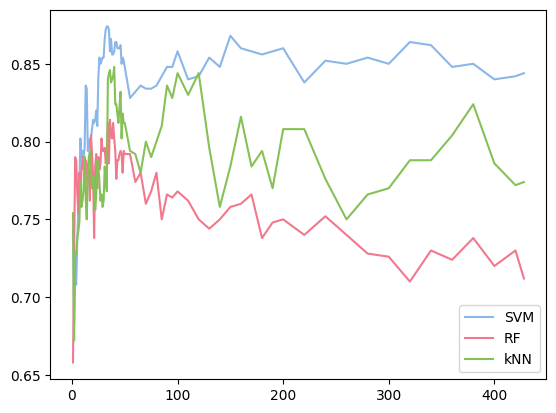

In [13]:
fig, ax = plt.subplots()
plt.plot(n_genes, accuracy.svm, color = '#8AB6E9')
plt.plot(n_genes, accuracy.rf, color = '#F1788D')
plt.plot(n_genes, accuracy.knn, color = '#86C157')
plt.legend(['SVM', 'RF', 'kNN'])
plt.show()
#fig.savefig('results/plot_precision.jpg', dpi=500)
plt.close(fig)

In [14]:
# Sacamos el número de genes y modelo que obtiene el mayor accuracy
n = accuracy.stack().idxmax()[0]
n

np.int64(33)

In [ ]:
# Sacamos los genes de la firma y los guardamos en un fichero de texto 
sel_genes = corr1_final.iloc[:n, :]['Genes'].to_list()
with open("results/08_gene_signature/genes.txt", "w") as file:
    for gen in sel_genes: 
        file.write(f'{gen}\n')